# Inference Demo: BiLSTM vs Transformer (ViHSD)

Notebook này hướng dẫn **load checkpoint** và **sử dụng** hai mô hình đã huấn luyện để:
1. **Phân loại văn bản** tiếng Việt tùy ý (CLEAN / OFFENSIVE / HATE)
2. **Trực quan hóa attention** của Transformer
3. **Đánh giá lại** trên tập test

Checkpoint lưu `state_dict` → phải khởi tạo kiến trúc đúng rồi mới `load_state_dict`.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Đảm bảo Python tìm được package src/
ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import Config, LABEL_NAMES, CKPT_DIR
from src.vocab import Vocab
from src.preprocessing import build_preprocessor
from src.models import BiLSTMClassifier, TransformerClassifier, count_params
from src.dataset import build_dataloaders

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.12.0+cu130


## 1. Khởi tạo Config và xây dựng Vocabulary

Vocabulary **chỉ xây trên train split** (tránh data leakage). Sau đó dùng chung
cho cả LSTM và Transformer vì hai mô hình dùng cùng một không gian token.

In [2]:
cfg = Config()          # dùng đúng siêu tham số như lúc training

# build_dataloaders xây vocab trên train, trả về loaders + vocab + meta
loaders, vocab, meta = build_dataloaders(cfg)
VOCAB_SIZE = len(vocab)

oov_str = {k: round(v, 3) for k, v in meta["oov"].items()}
print(f"Vocab size : {VOCAB_SIZE:,}")
print(f"Class counts (train): {meta['class_counts']}")
print(f"OOV rate   : {oov_str}")
print(f"Label map  : {dict(enumerate(LABEL_NAMES))}")

Vocab size : 5,737
Class counts (train): [19886, 1606, 2556]
OOV rate   : {'train': 0.013, 'dev': 0.021, 'test': 0.022}
Label map  : {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}


## 2. Load Checkpoint

Checkpoint lưu dưới dạng `state_dict` — chỉ chứa trọng số, không chứa kiến trúc.
Ta phải **tạo instance model trước**, rồi gọi `load_state_dict()`.

```
results/checkpoints/
├── lstm.pt          ← BiLSTMClassifier state_dict
└── transformer.pt   ← TransformerClassifier state_dict
```

In [3]:
def load_checkpoint(model_class, ckpt_name, vocab_size, cfg, device):
    """Tạo model, load state_dict, chuyển sang eval mode."""
    model = model_class(vocab_size, cfg).to(device)
    ckpt_path = CKPT_DIR / ckpt_name
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model


lstm_model = load_checkpoint(BiLSTMClassifier,    "lstm.pt",        VOCAB_SIZE, cfg, DEVICE)
tf_model   = load_checkpoint(TransformerClassifier, "transformer.pt", VOCAB_SIZE, cfg, DEVICE)

print(f"BiLSTM     : {count_params(lstm_model):,} tham số")
print(f"Transformer: {count_params(tf_model):,} tham số")
print("Cả hai ở chế độ eval() — Dropout tắt, BatchNorm dùng running stats.")

BiLSTM     : 2,012,683 tham số
Transformer: 1,962,827 tham số
Cả hai ở chế độ eval() — Dropout tắt, BatchNorm dùng running stats.


## 3. Hàm Inference

Quy trình cho một câu đầu vào:

```
text (str)
  → preprocess()        # chuẩn hóa unicode, teencode, emoji, ...
  → .split()            # tách token theo khoảng trắng
  → vocab.encode()      # token → index, <unk> nếu OOV
  → [:max_len]          # cắt nếu quá dài
  → tensor (1, L)       # thêm batch dim
  → model(x, mask)      # forward pass
  → softmax → argmax    # lấy nhãn
```

In [4]:
# Bộ tiền xử lý giống lúc training (clean=True, lowercase=True)
preprocessor = build_preprocessor(
    clean=cfg.data.clean,
    lowercase=cfg.data.lowercase,
    word_seg=cfg.data.word_segment,
)


def text_to_tensor(text, vocab, max_len, device):
    """Tiền xử lý và mã hóa một câu thành tensor (1, L)."""
    cleaned = preprocessor(text)
    tokens  = cleaned.split()
    ids     = vocab.encode(tokens)[:max_len]
    if not ids:
        ids = [1]               # <unk> cho câu rỗng
    x       = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)   # (1,L)
    mask    = (x != 0)                                                       # (1,L)
    lengths = torch.tensor([len(ids)], dtype=torch.long)                     # (1,)
    return x, mask, lengths, tokens


@torch.no_grad()
def predict(model, text, vocab, max_len, device):
    """Trả về (nhãn dự đoán, xác suất 3 lớp, danh sách token)."""
    x, mask, lengths, tokens = text_to_tensor(text, vocab, max_len, device)
    logits = model(x, mask, lengths)
    probs  = F.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    pred   = int(probs.argmax())
    return pred, probs, tokens


def print_prediction(text, model, name, vocab, cfg, device):
    pred, probs, tokens = predict(model, text, vocab, cfg.data.max_len, device)
    label = LABEL_NAMES[pred]
    bar   = " | ".join(f"{n}: {p:.2%}" for n, p in zip(LABEL_NAMES, probs))
    print(f"[{name}]")
    print(f"  Input : {text}")
    print(f"  Tokens: {tokens}")
    print(f"  Pred  : {label}  ({bar})")
    print()


print("Inference functions sẵn sàng.")

Inference functions sẵn sàng.


## 4. Demo: Phân loại văn bản tùy ý

Thay `CUSTOM_TEXTS` bằng câu bạn muốn kiểm tra.

In [5]:
CUSTOM_TEXTS = [
    # CLEAN
    "Hôm nay thời tiết đẹp quá, đi chơi thôi mọi người ơi!",
    "Bài hát này hay lắm, mình nghe đi nghe lại mãi",
    # OFFENSIVE
    "Ôi bố cái lũ thanh niên hãm lol đẹp mặt quá",
    "Thằng này ngu vl ko hiểu sao lại làm vậy dc :v",
    # HATE
    "Mấy đứa đó toàn loại rác rưởi, đáng bị đuổi hết",
    "dm bọn này ghét vcl, cho nó ra đường ăn xin đi",
]

print("=" * 60)
for text in CUSTOM_TEXTS:
    print_prediction(text, lstm_model, "BiLSTM",      vocab, cfg, DEVICE)
    print_prediction(text, tf_model,   "Transformer", vocab, cfg, DEVICE)
    print("-" * 60)

[BiLSTM]
  Input : Hôm nay thời tiết đẹp quá, đi chơi thôi mọi người ơi!
  Tokens: ['hôm', 'nay', 'thời', 'tiết', 'đẹp', 'quá', ',', 'đi', 'chơi', 'thôi', 'mọi', 'người', 'ơi', '!']
  Pred  : CLEAN  (CLEAN: 100.00% | OFFENSIVE: 0.00% | HATE: 0.00%)

[Transformer]
  Input : Hôm nay thời tiết đẹp quá, đi chơi thôi mọi người ơi!
  Tokens: ['hôm', 'nay', 'thời', 'tiết', 'đẹp', 'quá', ',', 'đi', 'chơi', 'thôi', 'mọi', 'người', 'ơi', '!']
  Pred  : CLEAN  (CLEAN: 99.96% | OFFENSIVE: 0.02% | HATE: 0.02%)

------------------------------------------------------------
[BiLSTM]
  Input : Bài hát này hay lắm, mình nghe đi nghe lại mãi
  Tokens: ['bài', 'hát', 'này', 'hay', 'lắm', ',', 'mình', 'nghe', 'đi', 'nghe', 'lại', 'mãi']
  Pred  : CLEAN  (CLEAN: 100.00% | OFFENSIVE: 0.00% | HATE: 0.00%)

[Transformer]
  Input : Bài hát này hay lắm, mình nghe đi nghe lại mãi
  Tokens: ['bài', 'hát', 'này', 'hay', 'lắm', ',', 'mình', 'nghe', 'đi', 'nghe', 'lại', 'mãi']
  Pred  : CLEAN  (CLEAN: 99.94% | OFFENS

In [6]:
# --- Nhập câu tùy ý ---
user_text = input("Nhập câu cần phân loại (Enter để bỏ qua): ").strip()
if user_text:
    print()
    print_prediction(user_text, lstm_model, "BiLSTM",      vocab, cfg, DEVICE)
    print_prediction(user_text, tf_model,   "Transformer", vocab, cfg, DEVICE)


[BiLSTM]
  Input : Vãi lồn thiệt
  Tokens: ['vãi', 'lồn', 'thiệt']
  Pred  : OFFENSIVE  (CLEAN: 0.01% | OFFENSIVE: 99.99% | HATE: 0.00%)

[Transformer]
  Input : Vãi lồn thiệt
  Tokens: ['vãi', 'lồn', 'thiệt']
  Pred  : OFFENSIVE  (CLEAN: 0.13% | OFFENSIVE: 99.87% | HATE: 0.01%)



## 5. Trực quan hóa Attention (Transformer)

Attention weight `α_{ij}` cho biết token thứ `i` "chú ý" bao nhiêu vào token `j`.
Ta lấy attention của **lớp encoder cuối**, trung bình qua 4 heads.

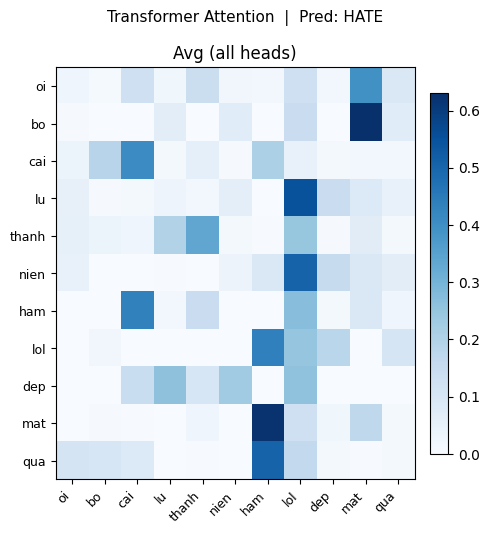

In [7]:
@torch.no_grad()
def get_attention(model, text, vocab, max_len, device):
    """Trả về (tokens, attn_matrix) với attn: (n_heads, L, L)."""
    x, mask, lengths, tokens = text_to_tensor(text, vocab, max_len, device)
    # return_attn=True → lớp cuối trả thêm attention weights
    logits, attn = model(x, mask, lengths, return_attn=True)
    # attn shape: (1, n_heads, L, L) → squeeze batch → (n_heads, L, L)
    attn_np = attn.squeeze(0).cpu().numpy()
    pred = LABEL_NAMES[int(logits.argmax(-1).item())]
    return tokens, attn_np, pred


def plot_attention(text, head_avg=True):
    tokens, attn, pred = get_attention(tf_model, text, vocab, cfg.data.max_len, DEVICE)
    L = len(tokens)
    attn = attn[:, :L, :L]             # cắt về đúng độ dài câu

    if head_avg:
        matrices = [attn.mean(axis=0)]
        titles   = ["Avg (all heads)"]
    else:
        matrices = list(attn)
        titles   = [f"Head {i+1}" for i in range(len(matrices))]

    n = len(matrices)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, max(4, L * 0.4 + 1)))
    if n == 1:
        axes = [axes]

    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap="Blues", aspect="auto", vmin=0)
        ax.set_xticks(range(L))
        ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
        ax.set_yticks(range(L))
        ax.set_yticklabels(tokens, fontsize=9)
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f'Transformer Attention  |  Pred: {pred}', fontsize=11)
    plt.tight_layout()
    plt.show()


# Thay bằng câu bất kỳ để xem attention
ATTN_TEXT = "Oi bo cai lu thanh nien ham lol dep mat qua"
plot_attention(ATTN_TEXT, head_avg=True)

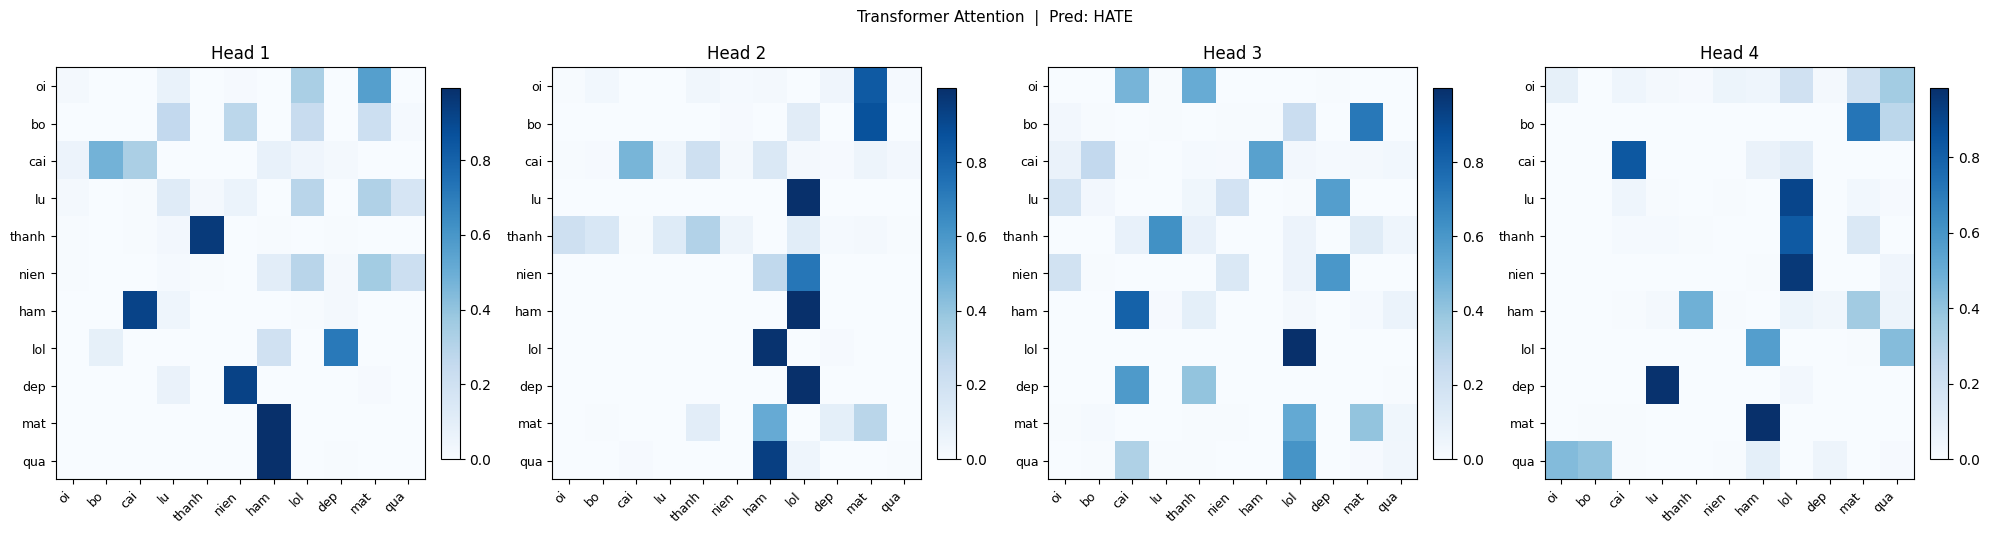

In [8]:
# Xem từng head riêng lẻ
plot_attention(ATTN_TEXT, head_avg=False)

## 6. Đánh giá lại trên Tập Test

Chạy cả hai mô hình qua toàn bộ test loader và in `classification_report`.

In [9]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Trả về (y_true, y_pred) trên toàn bộ loader."""
    model.eval()
    all_true, all_pred = [], []
    for x, mask, lengths, y in loader:
        x, mask, lengths = x.to(device), mask.to(device), lengths.to(device)
        logits = model(x, mask, lengths)
        preds  = logits.argmax(-1).cpu().numpy()
        all_true.extend(y.numpy())
        all_pred.extend(preds)
    return np.array(all_true), np.array(all_pred)


test_loader = loaders["test"]

print("Evaluating BiLSTM ...")
y_true, lstm_pred = evaluate(lstm_model, test_loader, DEVICE)
print(classification_report(y_true, lstm_pred, target_names=LABEL_NAMES, digits=4))

print("Evaluating Transformer ...")
_, tf_pred = evaluate(tf_model, test_loader, DEVICE)
print(classification_report(y_true, tf_pred, target_names=LABEL_NAMES, digits=4))

Evaluating BiLSTM ...
              precision    recall  f1-score   support

       CLEAN     0.9345    0.9097    0.9219      5548
   OFFENSIVE     0.3571    0.5068    0.4190       444
        HATE     0.5609    0.5291    0.5445       688

    accuracy                         0.8437      6680
   macro avg     0.6175    0.6485    0.6285      6680
weighted avg     0.8576    0.8437    0.8496      6680

Evaluating Transformer ...
              precision    recall  f1-score   support

       CLEAN     0.9436    0.8837    0.9127      5548
   OFFENSIVE     0.3343    0.5473    0.4150       444
        HATE     0.5073    0.5581    0.5315       688

    accuracy                         0.8278      6680
   macro avg     0.5950    0.6631    0.6197      6680
weighted avg     0.8582    0.8278    0.8404      6680



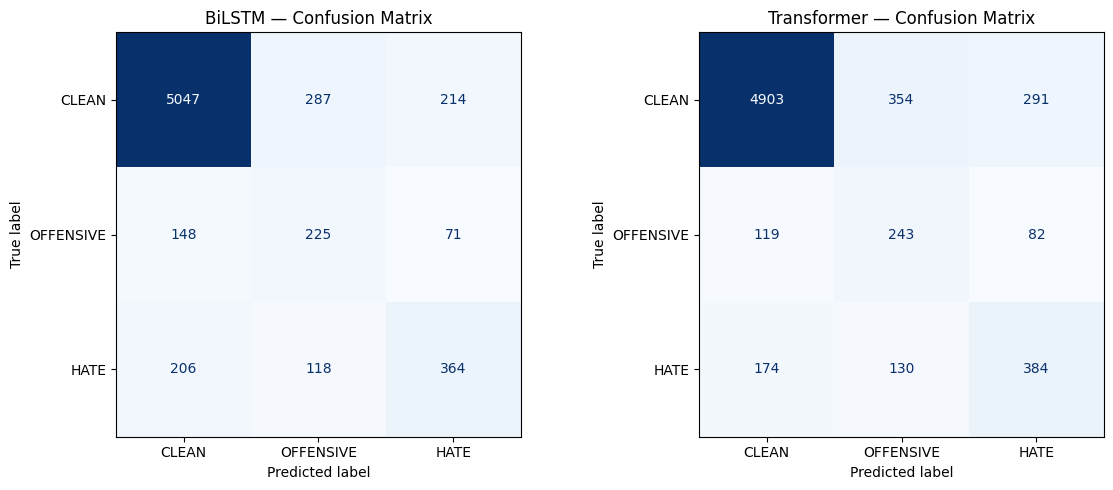

In [10]:
# Confusion Matrix song song
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
                             [lstm_pred, tf_pred],
                             ["BiLSTM", "Transformer"]):
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{title} — Confusion Matrix")

plt.tight_layout()
plt.show()

## 7. So sánh độ tin cậy (Confidence)

Phân phối xác suất tối đa (`max softmax`) theo nhãn thật — model tự tin đến đâu?

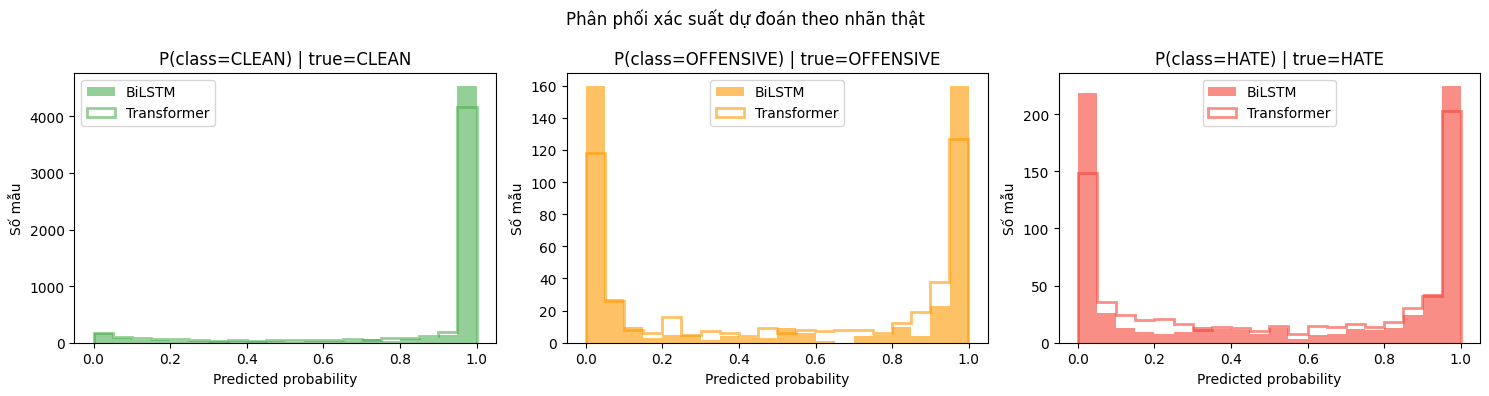

In [11]:
@torch.no_grad()
def collect_probs(model, loader, device):
    model.eval()
    all_probs, all_true = [], []
    for x, mask, lengths, y in loader:
        x, mask, lengths = x.to(device), mask.to(device), lengths.to(device)
        logits = model(x, mask, lengths)
        probs  = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
        all_true.extend(y.numpy())
    return np.vstack(all_probs), np.array(all_true)


lstm_probs, y_true_p = collect_probs(lstm_model, test_loader, DEVICE)
tf_probs,   _        = collect_probs(tf_model,   test_loader, DEVICE)

colors = ["#4CAF50", "#FF9800", "#F44336"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls_idx, (ax, lname) in enumerate(zip(axes, LABEL_NAMES)):
    mask_cls = y_true_p == cls_idx
    ax.hist(lstm_probs[mask_cls, cls_idx], bins=20, alpha=0.6,
            label="BiLSTM", color=colors[cls_idx])
    ax.hist(tf_probs[mask_cls, cls_idx],   bins=20, alpha=0.6,
            label="Transformer", color=colors[cls_idx],
            histtype="step", linewidth=2)
    ax.set_title(f"P(class={lname}) | true={lname}")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Số mẫu")
    ax.legend()

plt.suptitle("Phân phối xác suất dự đoán theo nhãn thật", fontsize=12)
plt.tight_layout()
plt.show()